# 🩺 Diabetes Onset Prediction — XGBoost Pipeline
**Dataset:** Pima Indians Diabetes (768 rows, 8 features + 1 target)  

## Cell 1 — Install Dependencies

In [3]:
import subprocess, sys

packages = ['xgboost', 'optuna', 'imbalanced-learn', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed ✅')

All packages installed ✅


## Cell 2 — Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('XGBoost version:', xgb.__version__)
print('Imports done ✅')

XGBoost version: 3.2.0
Imports done ✅


## Cell 3 — Load Data

In [7]:
df = pd.read_csv('pima-indians-diabetes.csv')

# Check what columns actually loaded
print('Columns found:', df.columns.tolist())

# Auto-fix: rename if short names are present
if 'class' in df.columns:
    df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    print('Columns renamed ✅')

print('Shape   :', df.shape)
print('Columns :', df.columns.tolist())
print('Outcome :', df['Outcome'].value_counts().to_dict())
df.head()

Columns found: ['Preg', 'Plas', 'Pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
Columns renamed ✅
Shape   : (768, 9)
Columns : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Outcome : {0: 500, 1: 268}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Cell 4 — Basic Stats

In [9]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## Cell 5 — EDA: Class Distribution

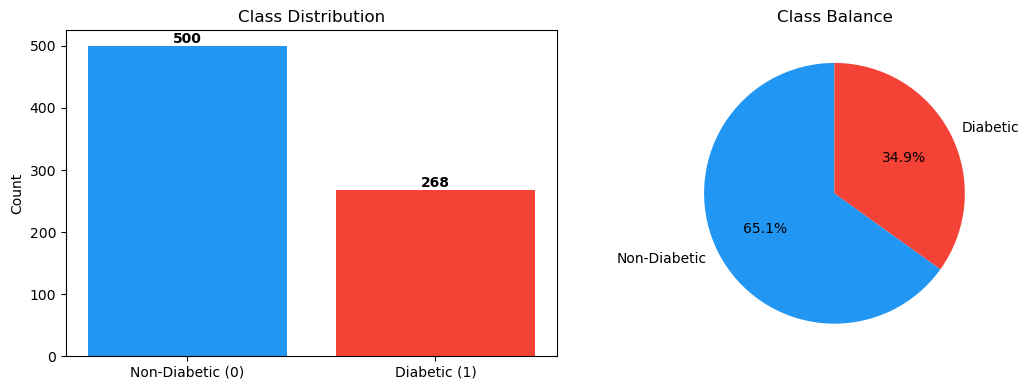

Class imbalance ratio: 1.87:1


In [11]:
counts = df['Outcome'].value_counts().sort_index()  # 0 first, 1 second

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Non-Diabetic (0)', 'Diabetic (1)'], counts.values, color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Non-Diabetic', 'Diabetic'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()
print(f'Class imbalance ratio: {counts[0]/counts[1]:.2f}:1')

## Cell 6 — EDA: Zero Value Analysis

Biologically Impossible Zero Values:
               Zero Count  Zero %
Glucose                 5     0.7
BloodPressure          35     4.6
SkinThickness         227    29.6
Insulin               374    48.7
BMI                    11     1.4


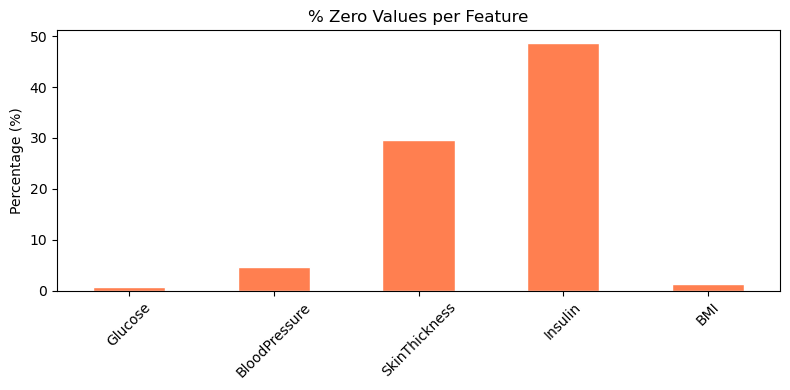

In [13]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_info = pd.DataFrame({
    'Zero Count': (df[zero_cols] == 0).sum(),
    'Zero %'    : ((df[zero_cols] == 0).sum() / len(df) * 100).round(1)
})
print('Biologically Impossible Zero Values:')
print(zero_info)

zero_info['Zero %'].plot(kind='bar', color='coral', figsize=(8, 4), edgecolor='white')
plt.title('% Zero Values per Feature')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cell 7 — EDA: Correlation Heatmap

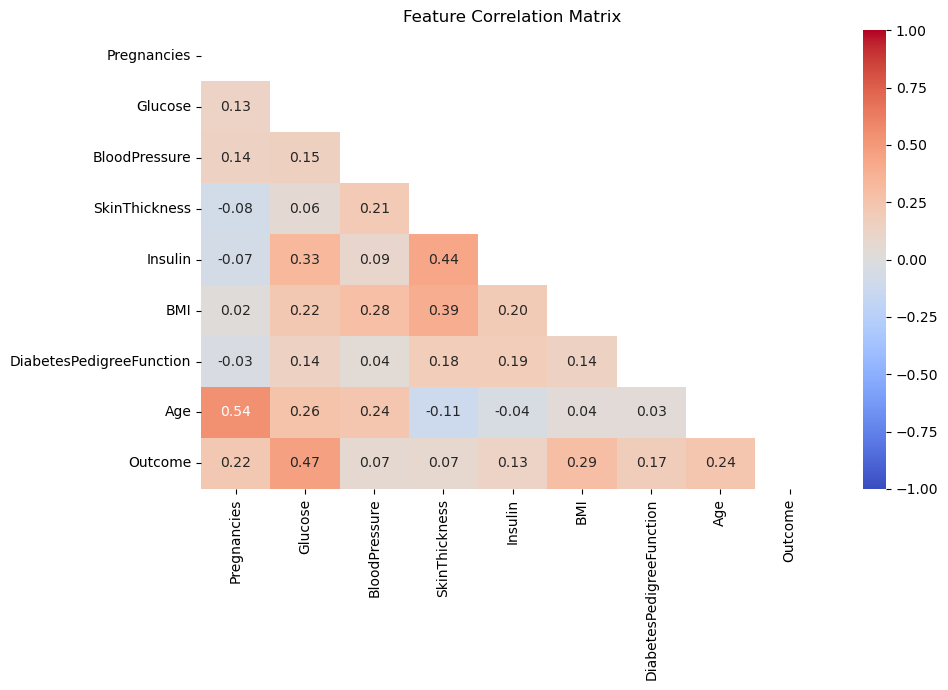

In [15]:
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Cell 8 — EDA: Feature Distributions

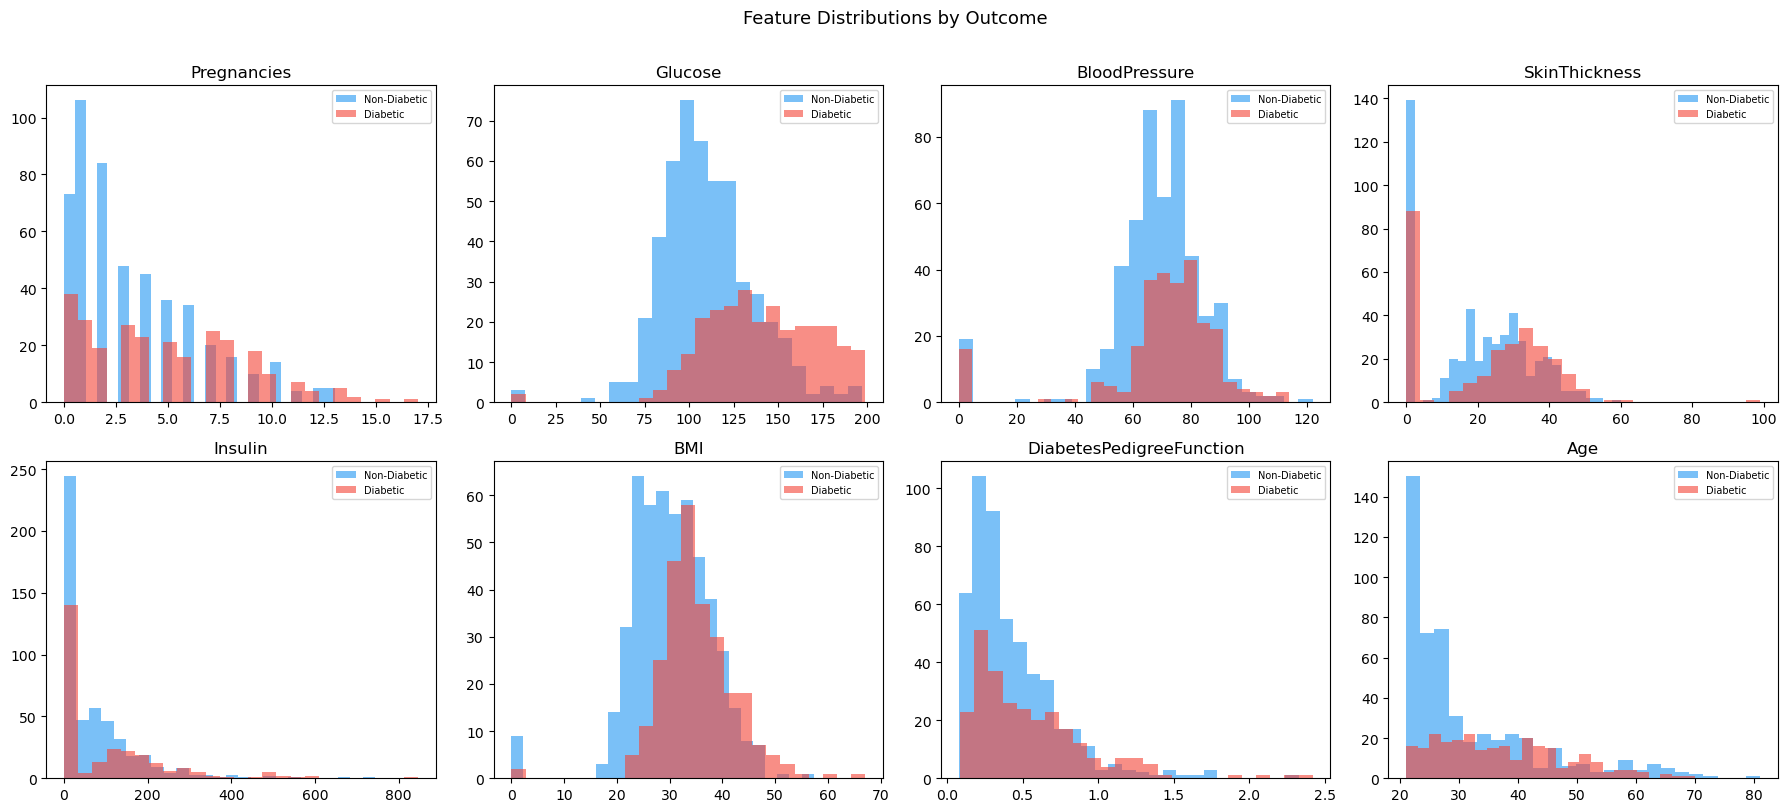

In [17]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0, '#2196F3', 'Non-Diabetic'), (1, '#F44336', 'Diabetic')]:
        axes[i].hist(df[df['Outcome'] == outcome][feat], bins=25,
                     alpha=0.6, color=color, label=label)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Cell 9 — KNN Imputation

In [19]:
df_clean = df.copy()

# Replace biologically impossible zeros with NaN
impute_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean[impute_cols] = df_clean[impute_cols].replace(0, np.nan)

print('NaN counts after marking zeros:')
print(df_clean.isnull().sum())

# KNN Imputation
X_raw = df_clean.drop('Outcome', axis=1)
y     = df_clean['Outcome'].values

imputer   = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=X_raw.columns
)

print('\nNaN after KNN imputation:', X_imputed.isnull().sum().sum())
print('KNN Imputation complete ✅')

NaN counts after marking zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

NaN after KNN imputation: 0
KNN Imputation complete ✅


## Cell 10 — Feature Engineering

In [21]:
def engineer_features(X):
    X = X.copy()

    # Interaction features
    X['Glucose_Insulin_Ratio'] = X['Glucose'] / (X['Insulin'] + 1)
    X['BMI_Age']               = X['BMI'] * X['Age']
    X['Glucose_BMI']           = X['Glucose'] * X['BMI']
    X['Preg_Age_Ratio']        = X['Pregnancies'] / (X['Age'] + 1)

    # Clinical risk bins
    X['Glucose_Risk'] = pd.cut(
        X['Glucose'], bins=[0, 100, 125, 200, 500], labels=[0,1,2,3]
    ).astype(float)

    X['BMI_Category'] = pd.cut(
        X['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0,1,2,3]
    ).astype(float)

    X['Age_Group'] = pd.cut(
        X['Age'], bins=[0, 30, 45, 60, 120], labels=[0,1,2,3]
    ).astype(float)

    return X

X_engineered = engineer_features(X_imputed)

print(f'Features before : {X_imputed.shape[1]}')
print(f'Features after  : {X_engineered.shape[1]}')
print('New features:', [c for c in X_engineered.columns if c not in X_imputed.columns])

Features before : 8
Features after  : 15
New features: ['Glucose_Insulin_Ratio', 'BMI_Age', 'Glucose_BMI', 'Preg_Age_Ratio', 'Glucose_Risk', 'BMI_Category', 'Age_Group']


In [39]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Cell 11 — Train/Test Split → SMOTE → Scaling

In [43]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

LogisticRegression()

In [45]:
# SMOTE on training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE — Train:', X_train_sm.shape)
print('Class counts:', pd.Series(y_train_sm).value_counts().to_dict())

After SMOTE — Train: (800, 8)
Class counts: {0: 400, 1: 400}


In [47]:
# Standard scaling
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done ✅')

Scaling done ✅


In [83]:
import pickle

# Save model
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved successfully ✅")

Saved successfully ✅


In [85]:
import os

print("Model size:", os.path.getsize("diabetes_model.pkl"))
print("Scaler size:", os.path.getsize("scaler.pkl"))

Model size: 634270
Scaler size: 833


## Cell 12 — Optuna Hyperparameter Tuning

In [51]:
XGB_VERSION = tuple(int(x) for x in xgb.__version__.split('.')[:2])

def make_xgb(params):
    p = params.copy()
    p['random_state'] = RANDOM_STATE
    p['eval_metric']  = 'logloss'
    if XGB_VERSION < (1, 6):
        p['use_label_encoder'] = False
    return XGBClassifier(**p)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 2.0),
    }
    model  = make_xgb(params)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_scaled, y_train_sm,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest CV Accuracy : {study.best_value:.4f}')
print('Best Parameters  :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV Accuracy : 0.8063
Best Parameters  :
  n_estimators: 381
  max_depth: 6
  learning_rate: 0.04160431586328556
  subsample: 0.8319545370753094
  colsample_bytree: 0.9011665679458987
  min_child_weight: 3
  gamma: 0.011385870228221573
  reg_alpha: 1.3991479586746736
  reg_lambda: 1.638728619801205


## Cell 13 — Train Final Model

In [52]:
final_model = make_xgb(study.best_params)
final_model.fit(X_train_scaled, y_train_sm)
print('Final model trained ✅')

Final model trained ✅


## Cell 14 — Threshold Optimization

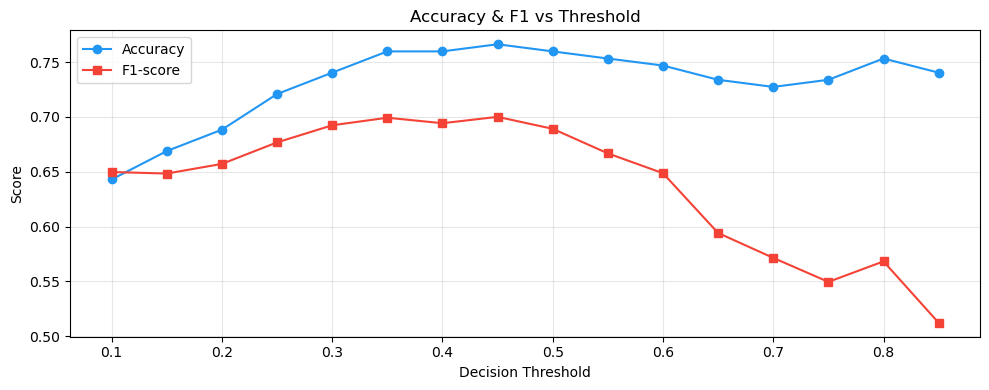

Best threshold: 0.45  →  Accuracy = 0.7662
 Threshold  Accuracy     F1
      0.10    0.6429 0.6497
      0.15    0.6688 0.6483
      0.20    0.6883 0.6571
      0.25    0.7208 0.6767
      0.30    0.7403 0.6923
      0.35    0.7597 0.6992
      0.40    0.7597 0.6942
      0.45    0.7662 0.7000
      0.50    0.7597 0.6891
      0.55    0.7532 0.6667
      0.60    0.7468 0.6486
      0.65    0.7338 0.5941
      0.70    0.7273 0.5714
      0.75    0.7338 0.5495
      0.80    0.7532 0.5682
      0.85    0.7403 0.5122


In [55]:
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

rows = []
for t in np.arange(0.10, 0.90, 0.05):
    y_pred_t = (y_prob > t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Accuracy' : round(accuracy_score(y_test, y_pred_t), 4),
        'F1'       : round(f1_score(y_test, y_pred_t, zero_division=0), 4)
    })

thresh_df = pd.DataFrame(rows)

plt.figure(figsize=(10, 4))
plt.plot(thresh_df['Threshold'], thresh_df['Accuracy'], 'o-', label='Accuracy', color='#2196F3')
plt.plot(thresh_df['Threshold'], thresh_df['F1'],       's-', label='F1-score',  color='#F44336')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Accuracy & F1 vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_row       = thresh_df.loc[thresh_df['Accuracy'].idxmax()]
BEST_THRESHOLD = best_row['Threshold']
print(f'Best threshold: {BEST_THRESHOLD}  →  Accuracy = {best_row["Accuracy"]}')
print(thresh_df.to_string(index=False))

## Cell 15 — Final Evaluation

In [57]:
y_pred_final = (y_prob > BEST_THRESHOLD).astype(int)

print('=' * 55)
print(f'  FINAL RESULTS  —  Threshold = {BEST_THRESHOLD}')
print('=' * 55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred_final,
                             target_names=['Non-Diabetic', 'Diabetic']))

  FINAL RESULTS  —  Threshold = 0.45
Accuracy : 0.7662
ROC-AUC  : 0.8196

              precision    recall  f1-score   support

Non-Diabetic       0.86      0.76      0.81       100
    Diabetic       0.64      0.78      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.77      0.77       154



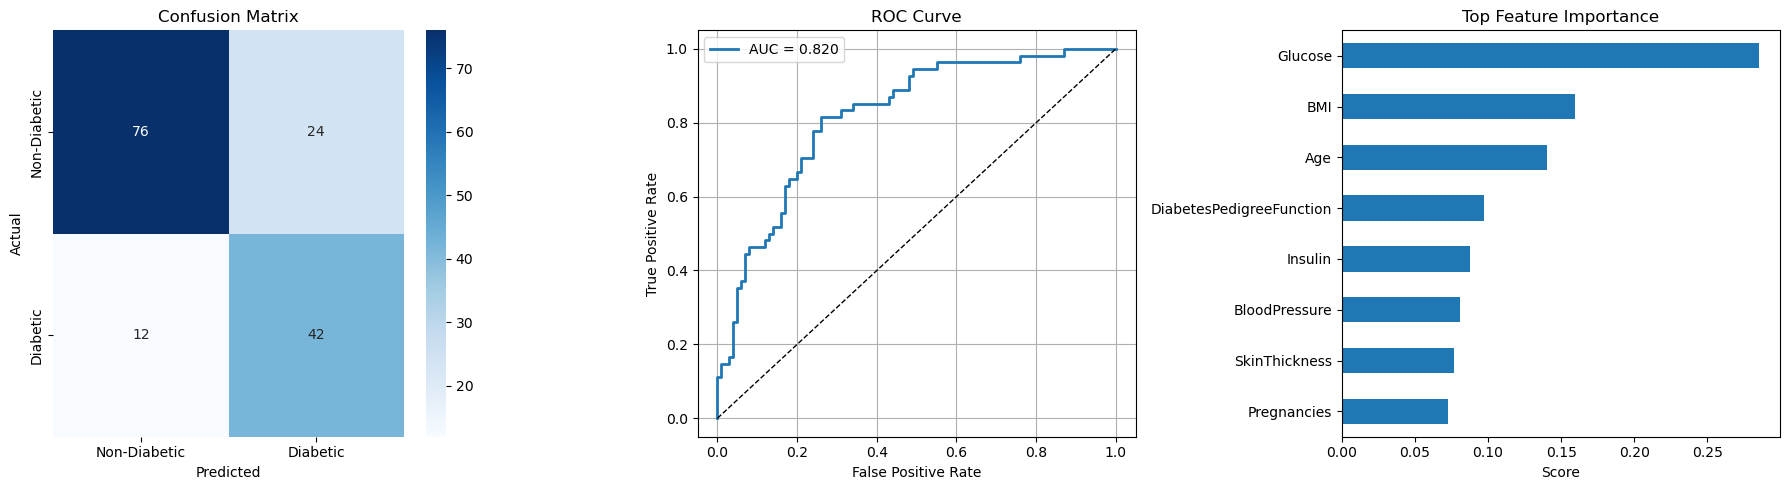

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------ Confusion Matrix ------------------
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ------------------ ROC Curve ------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True)

# ------------------ Feature Importance ------------------
feat_imp = pd.Series(
    final_model.feature_importances_,
    index=X.columns   # use X instead of X_engineered if unsure
).sort_values()

feat_imp.tail(10).plot(kind='barh', ax=axes[2])
axes[2].set_title('Top Feature Importance')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.show()

## Cell 16 — 10-Fold Cross Validation

10-Fold Cross-Validation:
  Scores : [0.7662 0.8182 0.7532 0.8312 0.8052 0.7403 0.6753 0.7403 0.75   0.6842]
  Mean   : 0.7564
  Std    : 0.0492


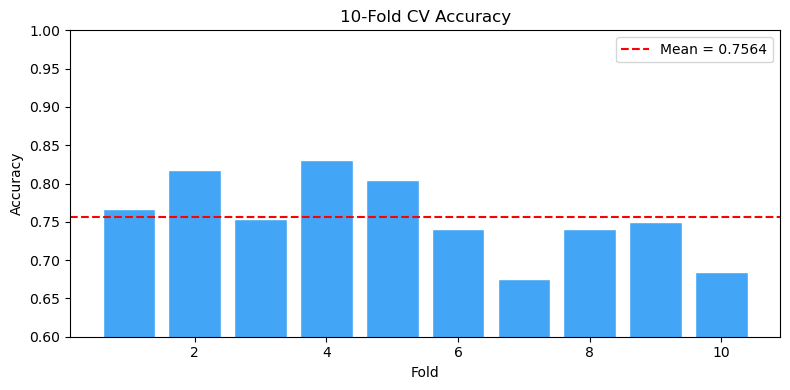

In [63]:
X_all_scaled = StandardScaler().fit_transform(X_engineered)
cv10         = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_scores    = cross_val_score(make_xgb(study.best_params), X_all_scaled, y,
                               cv=cv10, scoring='accuracy', n_jobs=-1)

print('10-Fold Cross-Validation:')
print(f'  Scores : {np.round(cv_scores, 4)}')
print(f'  Mean   : {cv_scores.mean():.4f}')
print(f'  Std    : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), cv_scores, color='#42A5F5', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold CV Accuracy')
plt.ylim(0.6, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 17 — Final Summary

In [65]:
print('\n' + '='*45)
print('          FINAL MODEL SUMMARY')
print('='*45)
print(f'  Test Accuracy    : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'  ROC-AUC          : {roc_auc_score(y_test, y_prob):.4f}')
print(f'  CV Mean Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Best Threshold   : {BEST_THRESHOLD}')
print(f'  Features Used    : {X_engineered.shape[1]} (8 raw + 7 engineered)')
print(f'  Imputation       : KNN (k=5)')
print(f'  Balancing        : SMOTE')
print(f'  Tuning           : Optuna (50 trials, 5-fold CV)')
print('='*45)


          FINAL MODEL SUMMARY
  Test Accuracy    : 0.7662
  ROC-AUC          : 0.8196
  CV Mean Accuracy : 0.7564 ± 0.0492
  Best Threshold   : 0.45
  Features Used    : 15 (8 raw + 7 engineered)
  Imputation       : KNN (k=5)
  Balancing        : SMOTE
  Tuning           : Optuna (50 trials, 5-fold CV)


In [79]:
print(final_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9011665679458987, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.011385870228221573, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.04160431586328556, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=381, n_jobs=None,
              num_parallel_tree=None, ...)


In [81]:
import pickle

# Save model
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved successfully ✅")

Saved successfully ✅


In [87]:
import os
import pickle

print("Current folder:", os.getcwd())

# Check model exists
print("Model object:", final_model)

# Save model
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Files saved ✅")

# Check file sizes immediately
print("Model size:", os.path.getsize("diabetes_model.pkl"))
print("Scaler size:", os.path.getsize("scaler.pkl"))

Current folder: C:\Users\SANJEEVANI
Model object: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9011665679458987, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.011385870228221573, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.04160431586328556, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=381, n_jobs=None,
              num_parallel_tree=None, ...)
Files saved ✅
Model size: 634270
Scaler size: 833


In [89]:
import os
import pickle

path = r"C:\Users\SANJEEVANI\OneDrive\Documents\Desktop\diabetes prediction"

with open(os.path.join(path, "diabetes_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)

with open(os.path.join(path, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("Saved in correct folder ✅")

Saved in correct folder ✅
